<div align="center">
<h1 style="color:rgb(121, 65, 6);">Speech Emotion Recognition</h1>
<h3>Feature Engineering</h3>
<a href="">Give Feedback</a> | <a href="">Bug report</a>

</div>

**Tags:** #ser #audio #feature-engineering #mel-scale

**Author:** [Ndeye Awa Salane](https://www.linkedin.com/in/ndeye-awa-salane-a93667230/)

**Last update:** 2025-04-18 (Created: 2025-04-16)

**Description:** This notebook explores audio features in general, with a special focus on those commonly used in machine learning models. We will extract a variety of audio features, visualize them whenever possible, and then transform these features into formats that are both usable and effective for classification tasks. The goal is to understand how different audio features capture important characteristics of sound and how they can be used to improve model performance.

## Table of Contents

1. [Import libraries](#import-libraries)
2. [Landscape of audio features](#landscape-of-audio-features)
3. [Feature Extraction](#feature-extraction)
4. [Feature Engineering and Preprocessing](#feature-engineering-and-preprocessing)
6. [Conclusions](#conclusions)
7. [Resources](#resources)

In [1]:
# pip install resampy  (uncomment if needed)

# Import libraries

In [2]:
import sys, importlib
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parent))

import IPython.display as ipd
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Force-reload so updated features.py is picked up
import src.config, src.features, src.training
for mod in [src.config, src.features, src.training]:
    importlib.reload(mod)

from src.config import RAVDESS_DIR, CREMA_DIR, DATA_RAW, DATA_PROCESSED, N_MFCC, SR, DURATION
from src.features import extract_features, extract_features_for_dataset, get_feature_names
from src.training import save_processed

sns.set(style="whitegrid")

print(f"Feature extraction config: N_MFCC={N_MFCC}, SR={SR}, DURATION={DURATION}")
print(f"Features per sample: {len(get_feature_names(N_MFCC))}")

Project root: /Users/ndeyeawasalane/Downloads/SER
Project root: /Users/ndeyeawasalane/Downloads/SER
Feature extraction config: N_MFCC=40, SR=22050, DURATION=3.0
Features per sample: 434


# Landscape of audio features

<div align="center">
    <img style='width:400px' src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*xTYCtcx_7otHVu-uToI9dA.png">
    <a style='text-decoration:underline; font-size:8px' href='https://aavos.eu/glossary/fourier-transform/'>Source: Aavos International</a>
</div>

Features are quantifiable properties of audio signals that allow us to describe and analyze sound in a structured way. As an audio is fundamentally a signal, it can be represented in the time domain as a waveform, where each moment in the audio corresponds to an amplitude value thus showing how the signal changes over time. Time-domain features, such as the amplitude envelope, root mean square (RMS) energy, and zero-crossing rate, capture the temporal characteristics of the audio directly from this waveform representation.

Alternatively, an audio can also be represented in the frequency domain, where the signal is considered in terms of its frequency components. In this view, we observe how much energy/amplitude is present at each frequency, rather than at each moment in time.  This transformation from time to frequency domain is typically done mathematical tools like the <a href='https://en.wikipedia.org/wiki/Fourier_transform'>Fourier Transform</a>.

Other features are the Mel Frequency Cepstral Coefficients (MFCCs) which are a way to capture the characteristics of audio by representing how humans naturally hear sound (Mel Scale) that basically reflects how our ears are more sensitive to differences in lower frequencies than higher ones. The result is a set of numbers (coefficients) that sum up the shape of the sound’s spectrum(Check this out for more about the Mel spectogram: [Understanding the Mel Spectrogram](https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53))

When dealing with music/song audio, we might wanna use features like chroma, which capture the intensity of each of the twelve different pitch classes (C, C#, D....) present in the audio, regardless of octave. 

Read more about audio features here: [Audio Features](https://ravinkumar.com/GenAiGuidebook/audio/audio_feature_extraction.html) (Very detailed overview by the way :) )


For our classification task, we will focus more on the Mel coefficients and see if potentially we can use (or cross them with) other relevant features in the time domain or frequency domain even though the original project only used Mel coefficients as features.

# Feature Extraction

Okay… let's take a look at how a Mel spectrogram is represented and how the Mel coefficients are represented as data structures depending on the emotions and see if we can see any correlations even before an actual model/classifier.

Just to see those relationships or correlations maybe, we will plot again the waveform of the audio and then the Mel spectrogram/coefficients.



/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling Rate: 22050
Audio Duration: 3.570249433106576 seconds


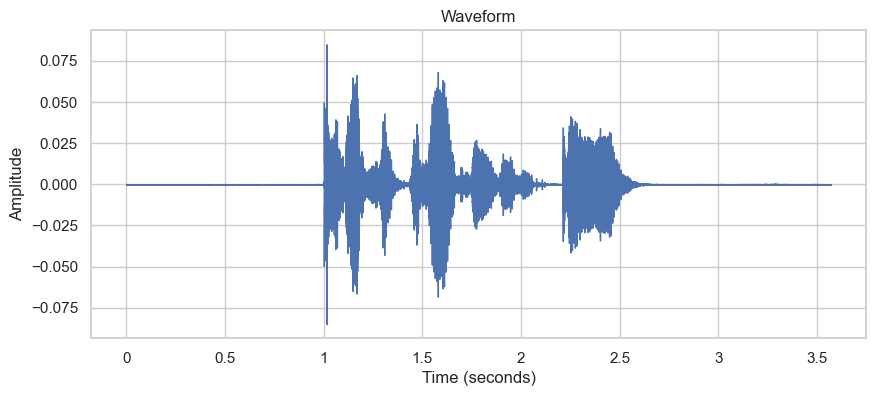

In [3]:
sample_path = str(RAVDESS_DIR / "Actor_23" / "03-01-07-01-01-01-23.wav")
audio_data, sr = librosa.load(sample_path)

print(f"Sampling Rate: {sr}")
print(f"Audio Duration: {librosa.get_duration(y=audio_data, sr=sr)} seconds")

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_data, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

ipd.Audio(sample_path)

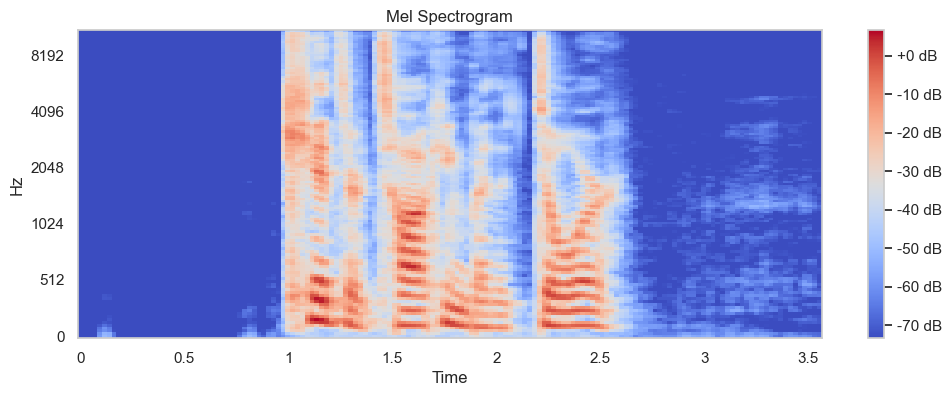

In [4]:
# Generate a spectrogram
spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sr)
log_spectrogram = librosa.power_to_db(spectrogram)

# Plot the spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(log_spectrogram, sr=sr, x_axis='time', y_axis='mel', cmap='coolwarm')
plt.title("Mel Spectrogram")
plt.colorbar(format='%+2.0f dB')
plt.show()

This is a time-frequency representation of the audio: in the x-axis, we have the time in seconds in this case and in the y-axis, we have the frequency in Hertz. The decibels (dB)represents the intensity/amplitude of each frequency and as you might guess high decibels represented by redish areas means loud sounds and lower decibels are presented by the blue zones, represent the quieter/calmer sounds and/or maybe moments of silence in the audio.

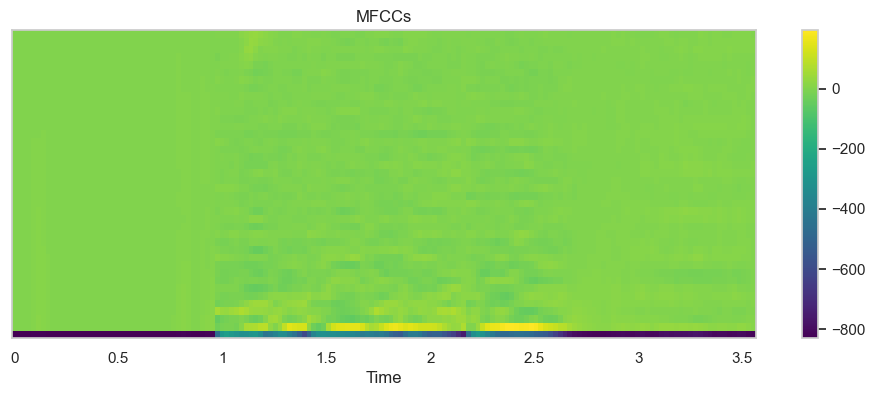

In [5]:
# Extract MFCCs from the audio file
mfccs = librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=40)

# Plot MFCCs
plt.figure(figsize=(12, 4))
librosa.display.specshow(mfccs, sr=sr, x_axis='time', cmap='viridis')
plt.title("MFCCs")
plt.colorbar()
plt.show()

The plots are quite similar, just the representations differs as these are just representation of the audio in different domains using : time domain (waveform), time-frequency domain (Mel scale)...

In [6]:
mfccs = pd.DataFrame(mfccs)
mfccs

,0,1,2,3,4,5,6,7,8,9,...,144,145,146,147,148,149,150,151,152,153
0,-830.43512,-830.43512,-830.43512,-830.43512,-826.362610,-823.154114,-824.149841,-828.968079,-830.43512,-830.43512,...,-796.720276,-808.246338,-805.339722,-804.818726,-811.798706,-808.729553,-800.902954,-803.977661,-815.194153,-821.964661
1,0.00000,0.00000,0.00000,0.00000,5.751169,10.247923,8.845234,2.073809,0.00000,0.00000,...,17.982880,16.583612,20.878349,20.712790,14.121017,15.921977,23.627224,23.289793,14.858839,8.785692
2,0.00000,0.00000,0.00000,0.00000,5.726515,10.104927,8.718204,2.071153,0.00000,0.00000,...,-7.440176,-3.068555,-0.798242,0.610699,-1.569100,-5.447490,-3.618194,-0.290557,3.192139,2.989057
3,0.00000,0.00000,0.00000,0.00000,5.685603,9.878587,8.516706,2.066730,0.00000,0.00000,...,0.831672,-5.638883,-6.721066,-1.378970,-1.163114,-6.866395,-8.609126,-7.057250,-1.580898,0.664866
4,0.00000,0.00000,0.00000,0.00000,5.628697,9.585462,8.254880,2.060549,0.00000,0.00000,...,1.511033,1.155388,0.476458,4.423076,5.824734,5.646014,3.908309,2.087981,1.291886,2.232480
5,0.00000,0.00000,0.00000,0.00000,5.556185,9.246058,7.950365,2.052617,0.00000,0.00000,...,4.984602,7.511908,8.176750,7.483205,8.991655,14.082924,12.357901,7.507471,3.258341,3.103995
6,0.00000,0.00000,0.00000,0.00000,5.468520,8.882563,7.622376,2.042950,0.00000,0.00000,...,2.608147,1.267529,0.456968,-0.948719,3.003838,6.536835,1.296310,-1.556343,-2.040837,0.752248
7,0.00000,0.00000,0.00000,0.00000,5.366277,8.516373,7.289729,2.031560,0.00000,0.00000,...,-14.830431,-12.481270,-13.914734,-13.465037,-7.640159,-9.919491,-15.368132,-13.387434,-8.735193,-2.445695
8,0.00000,0.00000,0.00000,0.00000,5.250115,8.165789,6.968860,2.018479,0.00000,0.00000,...,-15.324152,-14.218638,-14.980699,-12.851811,-8.056131,-14.276340,-16.500460,-13.624912,-8.544798,-3.280337
9,0.00000,0.00000,0.00000,0.00000,5.120782,7.844056,6.672263,2.003692,0.00000,0.00000,...,-0.839082,-2.659046,-4.423409,-0.756051,2.254692,-1.929475,-4.773874,-4.196265,-1.939555,-1.731715


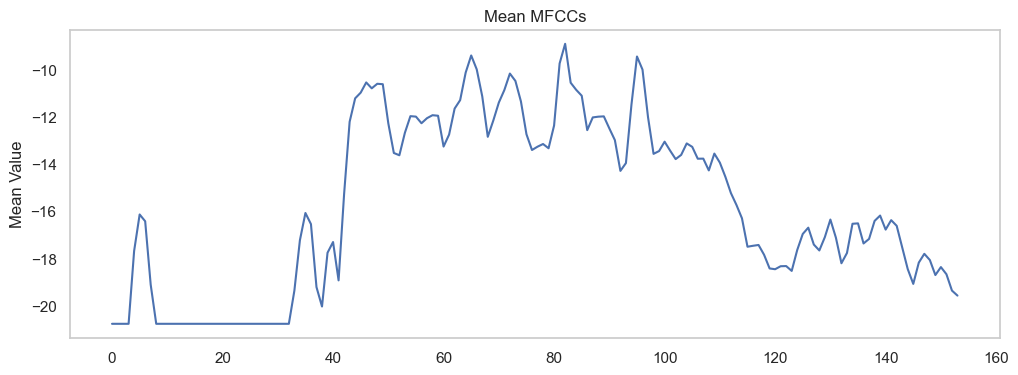

In [7]:
# take the mean of each row of mfccs and plot it
plt.figure(figsize=(12, 4))
plt.plot(mfccs.mean(axis=0))    
plt.title("Mean MFCCs")

# plt.xlabel("MFCC Coefficients")
plt.ylabel("Mean Value")
plt.grid()
plt.show()

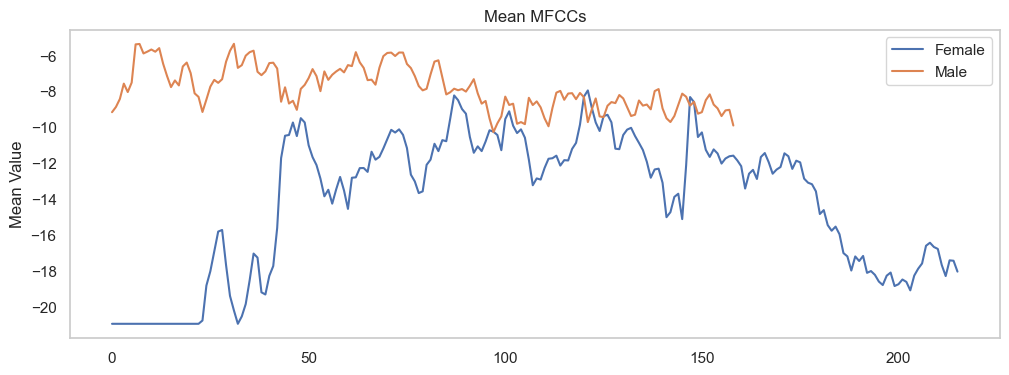

In [8]:
fem_path = str(RAVDESS_DIR / "Actor_23" / "03-01-07-01-01-01-23.wav")
male_path = str(CREMA_DIR / "1001_DFA_DIS_XX.wav")

fem, sr = librosa.load(fem_path, duration=2.5, sr=22050*2, offset=0.5)
fem_mfccs = librosa.feature.mfcc(y=fem, sr=sr, n_mfcc=40)

male, sr = librosa.load(male_path, duration=2.5, sr=22050*2, offset=0.5)
male_mfccs = librosa.feature.mfcc(y=male, sr=sr, n_mfcc=40)

plt.figure(figsize=(12, 4))
plt.plot(fem_mfccs.mean(axis=0), label="Female")
plt.plot(male_mfccs.mean(axis=0), label="Male")
plt.title("Mean MFCCs")
plt.ylabel("Mean Value")
plt.legend()
plt.grid()
plt.show()

Well nice disco

In [9]:
from src.data_loader import load_all_datasets, save_raw_dataset

# Rebuild the raw dataset with absolute paths (fixes old Windows backslash paths)
dataset = load_all_datasets()
save_raw_dataset(dataset)
print(f"Raw dataset: {dataset.shape}")
print(f"Sample path: {dataset['path'].iloc[0]}")
dataset.head()

Dropped 652 samples with excluded emotions: {'surprise'}
Raw dataset: (11510, 3)
Sample path: /Users/ndeyeawasalane/Downloads/SER/data/raw/surrey-audiovisual-expressed-emotion-savee/versions/1/ALL/JK_sa01.wav


,labels,source,path
0,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...
1,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...
2,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...
3,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...
4,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...


In [10]:
# This takes ~10 mins — extracts MFCCs for every audio file using src/features.py
df_features = extract_features_for_dataset(dataset)
print(f"Shape: {df_features.shape}")
df_features.head()

  Extracted 500/11510  (errors: 0)
  Extracted 1000/11510  (errors: 0)
  Extracted 1000/11510  (errors: 0)
  Extracted 1500/11510  (errors: 0)
  Extracted 1500/11510  (errors: 0)
  Extracted 2000/11510  (errors: 0)
  Extracted 2000/11510  (errors: 0)
  Extracted 2500/11510  (errors: 0)
  Extracted 2500/11510  (errors: 0)
  Extracted 3000/11510  (errors: 0)
  Extracted 3000/11510  (errors: 0)
  Extracted 3500/11510  (errors: 0)
  Extracted 3500/11510  (errors: 0)
  Extracted 4000/11510  (errors: 0)
  Extracted 4000/11510  (errors: 0)
  Extracted 4500/11510  (errors: 0)
  Extracted 4500/11510  (errors: 0)
  Extracted 5000/11510  (errors: 0)
  Extracted 5000/11510  (errors: 0)
  Extracted 5500/11510  (errors: 0)
  Extracted 5500/11510  (errors: 0)
  Extracted 6000/11510  (errors: 0)
  Extracted 6000/11510  (errors: 0)
  Extracted 6500/11510  (errors: 0)
  Extracted 6500/11510  (errors: 0)
  Extracted 7000/11510  (errors: 0)
  Extracted 7000/11510  (errors: 0)
  Extracted 7500/11510  (erro

/Users/ndeyeawasalane/Downloads/SER/src/features.py:72: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  float(sp_stats.skew(coeff)),
/Users/ndeyeawasalane/Downloads/SER/src/features.py:73: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  float(sp_stats.kurtosis(coeff)),
/Users/ndeyeawasalane/Downloads/SER/.venv/lib/python3.13/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


  Extracted 10500/11510  (errors: 0)
  Extracted 11000/11510  (errors: 0)
  Extracted 11000/11510  (errors: 0)
  Extracted 11500/11510  (errors: 0)
  Extracted 11510/11510  (errors: 0)
  Extracted 11500/11510  (errors: 0)
  Extracted 11510/11510  (errors: 0)
Shape: (11510, 437)
Shape: (11510, 437)


,labels,source,path,mfcc0_mean,mfcc0_std,mfcc0_min,mfcc0_max,mfcc0_skew,mfcc0_kurt,mfcc1_mean,...,zcr_mean,zcr_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std
0,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-326.265076,106.690926,-526.248291,-91.562363,-0.196094,-0.711901,118.734238,...,0.019952,0.016692,0.105557,0.066493,1035.065657,959.604720,1228.705512,611.031508,2032.833951,1902.435732
1,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-377.921875,99.548141,-552.131165,-166.276550,0.013079,-0.975216,126.090668,...,0.013861,0.013290,0.067715,0.038584,784.918417,662.336336,1096.746127,579.233967,1613.509827,1583.757645
2,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-393.836761,92.366028,-577.291199,-262.360138,-0.682388,-0.811730,141.822205,...,0.014668,0.013471,0.073243,0.034867,749.538828,773.858497,991.454752,630.354135,1392.806729,1660.287733
3,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-396.254150,98.001213,-563.343323,-214.401688,-0.325878,-1.092303,145.612320,...,0.016477,0.014648,0.069775,0.034715,644.807778,545.053493,917.271532,497.135774,1277.847829,1380.706737
4,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-334.690948,102.940590,-519.856506,-153.407104,-0.390660,-0.921238,131.068466,...,0.019231,0.016765,0.087224,0.054793,1013.625572,901.325821,1202.875943,714.087315,2011.765977,1940.824780


In [11]:
# Save the UN-SCALED feature dataset — scaling happens later in the modelling notebook
# to avoid data leakage (scaler must be fit on train set only)
save_processed(df_features, "dataset.csv")
print("Saved to data/processed/dataset.csv (unscaled)")

Saved to data/processed/dataset.csv (unscaled)


# Save features (unscaled)

> **Note:** We intentionally do NOT scale here. Scaling happens in the modelling notebook *after* the train/test split, so the scaler is fit on train data only — no data leakage.

In [12]:
# Quick sanity check — the processed dataset should have labels + source + path + feature columns
df_check = pd.read_csv(DATA_PROCESSED / "dataset.csv")
print(f"Columns: {len(df_check.columns)}, Rows: {len(df_check)}")
df_check.head()

Columns: 437, Rows: 11510


,labels,source,path,mfcc0_mean,mfcc0_std,mfcc0_min,mfcc0_max,mfcc0_skew,mfcc0_kurt,mfcc1_mean,...,zcr_mean,zcr_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std
0,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-326.265076,106.690926,-526.248291,-91.562363,-0.196094,-0.711901,118.734238,...,0.019952,0.016692,0.105557,0.066493,1035.065657,959.604720,1228.705512,611.031508,2032.833951,1902.435732
1,male_sad,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-377.921875,99.548141,-552.131165,-166.276550,0.013079,-0.975216,126.090668,...,0.013861,0.013290,0.067715,0.038584,784.918417,662.336336,1096.746127,579.233967,1613.509827,1583.757645
2,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-393.836761,92.366028,-577.291199,-262.360138,-0.682388,-0.811730,141.822205,...,0.014668,0.013471,0.073243,0.034867,749.538828,773.858497,991.454752,630.354135,1392.806729,1660.287733
3,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-396.254150,98.001213,-563.343323,-214.401688,-0.325878,-1.092303,145.612320,...,0.016477,0.014648,0.069775,0.034715,644.807778,545.053493,917.271532,497.135774,1277.847829,1380.706737
4,male_neutral,SAVEE,/Users/ndeyeawasalane/Downloads/SER/data/raw/s...,-334.690948,102.940590,-519.856506,-153.407104,-0.390660,-0.921238,131.068466,...,0.019231,0.016765,0.087224,0.054793,1013.625572,901.325821,1202.875943,714.087315,2011.765977,1940.824780


# Conclusions

# Resources

- [Hugging Face Audio Course](https://huggingface.co/learn/audio-course/en/chapter0/introduction)
- [Fourier Transform](https://en.wikipedia.org/wiki/Fourier_transform)
- [Audio Features](https://ravinkumar.com/GenAiGuidebook/audio/audio_feature_extraction.html)
- [Understanding the Mel Spectrogram](https://medium.com/analytics-vidhya/understanding-the-mel-spectrogram-fca2afa2ce53)